# Feature Visualization in Low-Dimensional Bottlenecks

Sweep through configurations where m=1,2 to visualize what learned features look like.

**Parameters:**
- n = [5, 10, 20] (number of input features)
- m = [1, 2] (bottleneck dimension - visualizable!)
- l = [1, 2, 4, 8] (encoder layers: 1=linear, 2+=nonlinear)
- S = [0, 0.9] (sparsity: 0=dense, 0.9=90% zeros)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from core import (
    Autoencoder,
    run_experiment,
    run_experiment_multi_seed,
    compute_feature_geometry,
    device
)

print(f"Using device: {device}")

Using device: cpu


In [2]:
def get_encoder_weights(model):
    """Extract encoder weights for visualization."""
    for name, param in model.encoder.named_parameters():
        if 'weight' in name:
            return param.detach().cpu().numpy()
    return None


def plot_features_1d(weights, ax, title=""):
    """Plot features on a 1D line (m=1)."""
    n_features = weights.shape[1]
    colors = plt.cm.tab10(np.linspace(0, 1, n_features))
    
    # Plot each feature as a point on the line
    for i in range(n_features):
        ax.scatter(weights[0, i], 0, c=[colors[i]], s=100, zorder=3)
        ax.annotate(f'f{i}', (weights[0, i], 0.05), ha='center', fontsize=8)
    
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5, alpha=0.3)
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-0.3, 0.3)
    ax.set_title(title, fontsize=9)
    ax.set_yticks([])


def plot_features_2d(weights, ax, title=""):
    """Plot features in 2D (m=2)."""
    n_features = weights.shape[1]
    colors = plt.cm.tab10(np.linspace(0, 1, min(n_features, 10)))
    
    # Unit circle
    theta = np.linspace(0, 2*np.pi, 100)
    ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.2)
    
    # Plot each feature as an arrow
    for i in range(n_features):
        color = colors[i % len(colors)]
        ax.arrow(0, 0, weights[0, i], weights[1, i],
                head_width=0.04, head_length=0.02,
                fc=color, ec=color, linewidth=1.5)
    
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect('equal')
    ax.axhline(y=0, color='k', linewidth=0.5, alpha=0.3)
    ax.axvline(x=0, color='k', linewidth=0.5, alpha=0.3)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

## Run Sweep

In [3]:
# Parameters
n_values = [4, 5, 6, 10]  # Number of features to try (10 for high compression)
m_values = [2]             # Bottleneck dimension (2 for visualization)
l_values = [1, 2, 4]       # Encoder depths
S_values = [0.9]           # Sparsity

# Store results
results = {}

total = len(n_values) * len(m_values) * len(l_values) * len(S_values)
pbar = tqdm(total=total, desc="Running experiments")

for n in n_values:
    for m in m_values:
        for l in l_values:
            for S in S_values:
                res = run_experiment_multi_seed(
                    n=n, m=m, l=l,
                    n_seeds=10,
                    S=S,
                    n_steps=10000,
                    importance_decay=0.7,
                    loss_threshold=0.01,
                    verbose=False
                )
                results[(n, m, l, S)] = res
                pbar.update(1)

pbar.close()
print(f"\nCompleted {len(results)} experiments")
print(f"Configurations: n={n_values}, m={m_values}, l={l_values}, S={S_values}")

Running experiments:   0%|          | 0/12 [00:00<?, ?it/s]

Running experiments:   8%|▊         | 1/12 [00:02<00:25,  2.32s/it]

Running experiments:  17%|█▋        | 2/12 [00:05<00:31,  3.12s/it]

Running experiments:  25%|██▌       | 3/12 [00:36<02:20, 15.66s/it]

Running experiments:  33%|███▎      | 4/12 [00:38<01:21, 10.24s/it]

...

Running experiments:  83%|████████▎ | 10/12 [01:06<00:09,  4.58s/it]

Running experiments:  92%|█████████▏| 11/12 [01:10<00:04,  4.32s/it]

Running experiments: 100%|██████████| 12/12 [01:16<00:00,  4.88s/it]

Running experiments: 100%|██████████| 12/12 [01:16<00:00,  6.39s/it]


Completed 12 experiments
Configurations: n=[4, 5, 6, 10], m=[2], l=[1, 2, 4], S=[0.9]


## Summary Statistics

In [4]:
import pandas as pd

# Compile results into dataframe
rows = []
for (n, m, l, S), res in results.items():
    rows.append({
        'n': n, 'm': m, 'l': l, 'S': S,
        'pct_active': f"{100*(1-S):.0f}%",
        'final_loss': res['final_loss'],
        'linearity_score': res['linearity_score'],
        'nonlinear_gain': res['nonlinear_gain'],
        'min_norm': res['min_norm'],
        'min_angle': res['min_angle'],
        'best_seed': res['best_seed'],
    })

df = pd.DataFrame(rows)
df = df.sort_values(['S', 'm', 'n', 'l'])
df

,n,m,l,S,pct_active,final_loss,linearity_score,nonlinear_gain,min_norm,min_angle,best_seed
0,4,2,1,0.9,10%,0.001054,1.000000,-1.032300e-07,0.990973,89.833260,0
1,4,2,2,0.9,10%,0.008497,0.999861,-9.760635e-05,0.227202,65.680420,0
2,4,2,4,0.9,10%,0.001154,0.892421,8.271175e-01,0.179600,31.061201,4
3,5,2,1,0.9,10%,0.002273,1.000000,0.000000e+00,0.003645,6.621994,0
4,5,2,2,0.9,10%,0.005064,0.979618,4.820369e-02,0.374941,53.709637,0
5,5,2,4,0.9,10%,0.001332,0.934220,5.193312e-01,0.636652,60.495094,1
6,6,2,1,0.9,10%,0.002814,1.000000,0.000000e+00,0.002989,15.369232,0
7,6,2,2,0.9,10%,0.001733,0.949430,2.612003e-01,0.375898,39.710136,0
8,6,2,4,0.9,10%,0.009690,0.858671,1.487495e-01,0.163498,3.384082,0
9,10,2,1,0.9,10%,0.003260,1.000000,9.882542e-08,0.000935,2.259061,0


In [5]:
# Compare linear (l=1) vs nonlinear (l>1) encoders
print("Average nonlinear_gain by depth:")
print(df.groupby('l')['nonlinear_gain'].mean())

print("\nAverage nonlinear_gain by sparsity:")
print(df.groupby('S')['nonlinear_gain'].mean())

Average nonlinear_gain by depth:
l
1   -1.101145e-09
2    1.250557e-01
4    4.499581e-01
Name: nonlinear_gain, dtype: float64

Average nonlinear_gain by sparsity:
S
0.9    0.191671
Name: nonlinear_gain, dtype: float64


## Observations

Key things to look for:
1. **l=1 (linear)**: Features should form polytope-like arrangements (pentagon for n=5, m=2)
2. **l>1 (nonlinear)**: Do features look different? More/less structured?
3. **S=0 (dense)**: Expect orthogonal features (fewer can fit)
4. **S=0.9 (sparse)**: Expect superposition (more features packed in)
5. **m=1**: Only positive/negative distinction possible
6. **m=2**: Rich 2D geometry possible

---

# Visualizing Nonlinearity in Feature Encodings

The weight visualizations above always show "linear" arrows because we're only seeing the final layer's weights. For nonlinear encoders (l>1), the effective "feature direction" depends on the input location.

**Key insight**:
- Linear encoder: same mapping everywhere (input-independent)
- Nonlinear encoder: mapping varies by input region

The following visualizations reveal this difference.

## 1. Feature Activation Trajectories

For each feature i, sweep its value from 0 to 1 (keeping others at 0) and plot the trajectory in z-space.

- **Linear encoder**: Straight line from origin
- **Nonlinear encoder**: Potentially curved path

In [6]:
import torch

def plot_feature_trajectories(model, n_points=50, ax=None, title=""):
    """Plot how each feature maps to z-space as its value varies 0→1.

    For a linear encoder, trajectories are straight lines.
    For a nonlinear encoder, trajectories may curve.
    """
    model.eval()
    n_features = model.n

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    colors = plt.cm.tab10(np.linspace(0, 1, min(n_features, 10)))

    # Unit circle for reference
    theta = np.linspace(0, 2*np.pi, 100)
    ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.15, linewidth=1)

    with torch.no_grad():
        for i in range(n_features):
            # Create inputs where only feature i varies from 0 to 1
            x = torch.zeros(n_points, n_features, device=device)
            x[:, i] = torch.linspace(0, 1, n_points)

            # Encode
            z = model.encode(x).cpu().numpy()

            # Plot trajectory
            color = colors[i % len(colors)]
            ax.plot(z[:, 0], z[:, 1], '-', color=color, linewidth=2, alpha=0.8)
            # Mark start (0) and end (1) points
            ax.scatter(z[0, 0], z[0, 1], color=color, s=30, marker='o', alpha=0.5)
            ax.scatter(z[-1, 0], z[-1, 1], color=color, s=80, marker='o', edgecolors='black', linewidth=1)
            ax.annotate(f'f{i}', (z[-1, 0], z[-1, 1]), fontsize=8,
                       xytext=(3, 3), textcoords='offset points')

    ax.axhline(y=0, color='k', linewidth=0.5, alpha=0.3)
    ax.axvline(x=0, color='k', linewidth=0.5, alpha=0.3)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('z₀')
    ax.set_ylabel('z₁')

    return ax


def compute_trajectory_curvature(model, n_points=50):
    """Compute curvature metric for each feature's trajectory.

    Returns ratio of arc length to chord length.
    Linear trajectory: ratio = 1.0
    Curved trajectory: ratio > 1.0
    """
    model.eval()
    n_features = model.n
    curvatures = []

    with torch.no_grad():
        for i in range(n_features):
            x = torch.zeros(n_points, n_features, device=device)
            x[:, i] = torch.linspace(0, 1, n_points)
            z = model.encode(x).cpu().numpy()

            # Arc length (sum of segment lengths)
            segments = np.diff(z, axis=0)
            arc_length = np.sum(np.linalg.norm(segments, axis=1))

            # Chord length (straight line distance)
            chord_length = np.linalg.norm(z[-1] - z[0])

            if chord_length > 1e-6:
                curvatures.append(arc_length / chord_length)
            else:
                curvatures.append(1.0)

    return curvatures

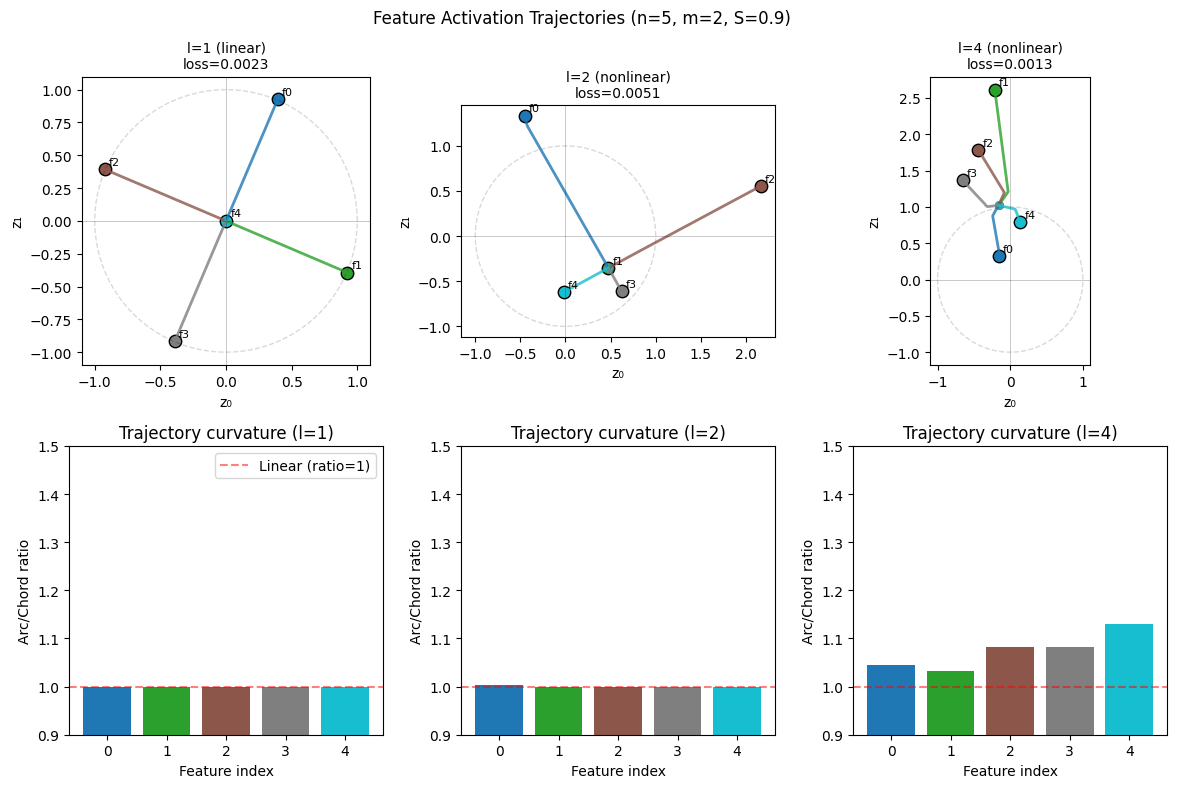


Trajectory Curvature Summary for n=5 (arc/chord ratio, 1.0 = straight):
  l=1: mean=1.0000, max=1.0000
  l=2: mean=1.0005, max=1.0025
  l=4: mean=1.0747, max=1.1290


In [7]:
# =====================================================
# CONFIGURE: Choose which n to visualize
# =====================================================
n_to_show = 5  # Options: 4, 5, 6, or 10 (high compression)
# =====================================================

m, S = 2, S_values[0]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i, l in enumerate([1, 2, 4]):
    res = results.get((n_to_show, m, l, S))
    if res is None:
        print(f"No results for n={n_to_show}, m={m}, l={l}, S={S}")
        continue

    model = res['model']

    # Top row: trajectories
    plot_feature_trajectories(model, ax=axes[0, i],
                             title=f"l={l} ({'linear' if l==1 else 'nonlinear'})\nloss={res['final_loss']:.4f}")

    # Bottom row: curvature analysis
    curvatures = compute_trajectory_curvature(model)
    axes[1, i].bar(range(len(curvatures)), curvatures, 
                   color=plt.cm.tab10(np.linspace(0, 1, len(curvatures))))
    axes[1, i].axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Linear (ratio=1)')
    axes[1, i].set_xlabel('Feature index')
    axes[1, i].set_ylabel('Arc/Chord ratio')
    axes[1, i].set_title(f'Trajectory curvature (l={l})')
    axes[1, i].set_ylim(0.9, max(1.5, max(curvatures) * 1.1))
    if i == 0:
        axes[1, i].legend()

fig.suptitle(f'Feature Activation Trajectories (n={n_to_show}, m={m}, S={S})', fontsize=12)
plt.tight_layout()
plt.show()

# Print curvature summary
print(f"\nTrajectory Curvature Summary for n={n_to_show} (arc/chord ratio, 1.0 = straight):")
for l in [1, 2, 4]:
    res = results.get((n_to_show, m, l, S))
    if res:
        curvs = compute_trajectory_curvature(res['model'])
        print(f"  l={l}: mean={np.mean(curvs):.4f}, max={np.max(curvs):.4f}")

## 2. Superposition Test: Two-Feature Encoding

Test additivity: does z(f₁+f₂) = z(f₁) + z(f₂)?

- **Linear encoder**: Perfect additivity (vectors sum exactly)
- **Nonlinear encoder**: Interference patterns (actual ≠ predicted sum)

In [8]:
def plot_superposition_test(model, feature_pairs=None, ax=None, title=""):
    """Show how combined features differ from sum of individual encodings.

    For each pair (i,j):
      z_i = encode([0...1_i...0])
      z_j = encode([0...1_j...0])
      z_ij = encode([0...1_i...1_j...0])

    Plot z_i, z_j, z_i+z_j (linear prediction), and z_ij (actual)
    """
    model.eval()
    n_features = model.n

    if feature_pairs is None:
        # Default: first few pairs
        feature_pairs = [(0, 1), (0, 2), (1, 2)]
        feature_pairs = [(i, j) for i, j in feature_pairs if i < n_features and j < n_features]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    colors = plt.cm.Set1(np.linspace(0, 1, len(feature_pairs)))

    # Unit circle
    theta = np.linspace(0, 2*np.pi, 100)
    ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.15, linewidth=1)

    interference_errors = []

    with torch.no_grad():
        for idx, (i, j) in enumerate(feature_pairs):
            color = colors[idx]

            # Single feature encodings
            x_i = torch.zeros(1, n_features, device=device)
            x_i[0, i] = 1.0
            z_i = model.encode(x_i).cpu().numpy()[0]

            x_j = torch.zeros(1, n_features, device=device)
            x_j[0, j] = 1.0
            z_j = model.encode(x_j).cpu().numpy()[0]

            # Combined encoding (actual)
            x_ij = torch.zeros(1, n_features, device=device)
            x_ij[0, i] = 1.0
            x_ij[0, j] = 1.0
            z_ij_actual = model.encode(x_ij).cpu().numpy()[0]

            # Linear prediction (sum)
            z_ij_predicted = z_i + z_j

            # Interference error
            error = np.linalg.norm(z_ij_actual - z_ij_predicted)
            interference_errors.append((i, j, error))

            # Plot individual features as thin arrows
            ax.arrow(0, 0, z_i[0], z_i[1], head_width=0.03, head_length=0.02,
                    fc=color, ec=color, alpha=0.4, linewidth=1)
            ax.arrow(0, 0, z_j[0], z_j[1], head_width=0.03, head_length=0.02,
                    fc=color, ec=color, alpha=0.4, linewidth=1)

            # Plot predicted (dashed) vs actual (solid)
            ax.scatter(*z_ij_predicted, color=color, marker='x', s=100, linewidth=2,
                      label=f'f{i}+f{j} predicted' if idx == 0 else '')
            ax.scatter(*z_ij_actual, color=color, marker='o', s=100, edgecolors='black',
                      label=f'f{i}+f{j} actual' if idx == 0 else '')

            # Line connecting predicted to actual (shows interference)
            ax.plot([z_ij_predicted[0], z_ij_actual[0]],
                   [z_ij_predicted[1], z_ij_actual[1]],
                   '--', color=color, alpha=0.7, linewidth=1.5)

            # Annotate
            ax.annotate(f'({i},{j})', z_ij_actual, fontsize=8,
                       xytext=(5, 5), textcoords='offset points')

    ax.axhline(y=0, color='k', linewidth=0.5, alpha=0.3)
    ax.axvline(x=0, color='k', linewidth=0.5, alpha=0.3)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('z₀')
    ax.set_ylabel('z₁')
    ax.legend(loc='upper right', fontsize=8)

    return interference_errors


def compute_additivity_violation(model, n_pairs=10):
    """Compute average additivity violation across random feature pairs.

    Returns mean ||z(fi+fj) - (z(fi) + z(fj))|| / ||z(fi) + z(fj)||
    """
    model.eval()
    n_features = model.n

    violations = []

    with torch.no_grad():
        pairs_tested = 0
        for i in range(n_features):
            for j in range(i+1, n_features):
                if pairs_tested >= n_pairs:
                    break

                x_i = torch.zeros(1, n_features, device=device)
                x_i[0, i] = 1.0
                z_i = model.encode(x_i)

                x_j = torch.zeros(1, n_features, device=device)
                x_j[0, j] = 1.0
                z_j = model.encode(x_j)

                x_ij = torch.zeros(1, n_features, device=device)
                x_ij[0, i] = 1.0
                x_ij[0, j] = 1.0
                z_ij = model.encode(x_ij)

                predicted = z_i + z_j
                error = torch.norm(z_ij - predicted).item()
                norm = torch.norm(predicted).item()

                if norm > 1e-6:
                    violations.append(error / norm)

                pairs_tested += 1
            if pairs_tested >= n_pairs:
                break

    return np.mean(violations) if violations else 0.0

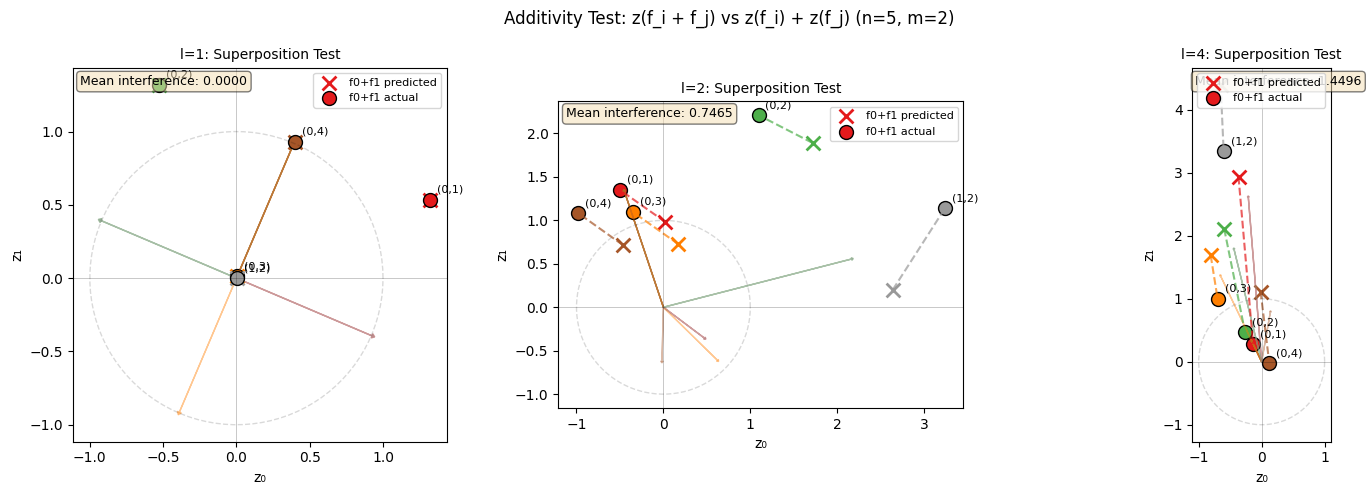


Additivity Violation for n=5 (relative error, 0 = perfectly linear):
  l=1: 0.0000
  l=2: 0.4839
  l=4: 0.5244


In [9]:
# Plot superposition test for different depths (uses n_to_show from above)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

n, m, S = n_to_show, 2, S_values[0]
pairs = [(i, j) for i in range(n) for j in range(i+1, n)][:5]  # First 5 pairs

for i, l in enumerate([1, 2, 4]):
    res = results.get((n, m, l, S))
    if res is None:
        continue

    model = res['model']
    errors = plot_superposition_test(model, feature_pairs=pairs, ax=axes[i],
                                     title=f"l={l}: Superposition Test")

    mean_error = np.mean([e[2] for e in errors])
    axes[i].text(0.02, 0.98, f'Mean interference: {mean_error:.4f}',
                transform=axes[i].transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle(f'Additivity Test: z(f_i + f_j) vs z(f_i) + z(f_j) (n={n}, m={m})', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nAdditivity Violation for n={n} (relative error, 0 = perfectly linear):")
for l in [1, 2, 4]:
    res = results.get((n, m, l, S))
    if res:
        violation = compute_additivity_violation(res['model'])
        print(f"  l={l}: {violation:.4f}")

## 3. Jacobian Variation Across Input Space

The Jacobian ∂z/∂x at a point shows local feature directions.

- **Linear encoder**: Same Jacobian everywhere
- **Nonlinear encoder**: Jacobian varies with input

In [10]:
def compute_jacobian(model, x):
    """Compute Jacobian ∂z/∂x at input x.

    Returns (m, n) matrix where J[i,j] = ∂z_i/∂x_j
    """
    x = x.clone().detach().requires_grad_(True)
    z = model.encode(x)

    jacobian = torch.zeros(model.m, model.n, device=device)
    for i in range(model.m):
        if x.grad is not None:
            x.grad.zero_()
        z[0, i].backward(retain_graph=True)
        jacobian[i] = x.grad[0]

    return jacobian.detach()


def visualize_jacobian_variation(model, n_samples=20, ax=None, title=""):
    """Show how feature directions (Jacobian columns) change across inputs.

    For m=2, plot Jacobian columns as arrows from different input conditions.
    Color coding: each input point gets a color, arrows show feature directions at that point.
    """
    model.eval()

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    # Generate diverse input points
    np.random.seed(42)
    inputs = []

    # Single feature activations
    for i in range(min(model.n, 5)):
        x = torch.zeros(1, model.n, device=device)
        x[0, i] = np.random.uniform(0.3, 1.0)
        inputs.append(x)

    # Random sparse combinations
    for _ in range(n_samples - len(inputs)):
        x = torch.zeros(1, model.n, device=device)
        active = np.random.choice(model.n, size=np.random.randint(1, 3), replace=False)
        for idx in active:
            x[0, idx] = np.random.uniform(0.2, 1.0)
        inputs.append(x)

    # Compute Jacobians at each input
    jacobians = []
    for x in inputs:
        jac = compute_jacobian(model, x)
        jacobians.append(jac.cpu().numpy())

    # For visualization: pick one feature and show how its direction varies
    feature_idx = 0  # Focus on first feature

    colors = plt.cm.viridis(np.linspace(0, 1, len(inputs)))

    # Unit circle
    theta = np.linspace(0, 2*np.pi, 100)
    ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.15, linewidth=1)

    # Plot feature direction at each input
    for i, (x, jac) in enumerate(zip(inputs, jacobians)):
        # Jacobian column = direction for this feature
        direction = jac[:, feature_idx]

        # Normalize for visualization
        norm = np.linalg.norm(direction)
        if norm > 1e-6:
            direction_normalized = direction / norm * 0.8  # Scale for visibility

            ax.arrow(0, 0, direction_normalized[0], direction_normalized[1],
                    head_width=0.03, head_length=0.02,
                    fc=colors[i], ec=colors[i], alpha=0.6, linewidth=1.5)

    ax.axhline(y=0, color='k', linewidth=0.5, alpha=0.3)
    ax.axvline(x=0, color='k', linewidth=0.5, alpha=0.3)
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_aspect('equal')
    ax.set_title(f"{title}\n(feature 0 direction at {len(inputs)} input points)", fontsize=10)
    ax.set_xlabel('z₀')
    ax.set_ylabel('z₁')

    # Compute variance in directions
    directions = np.array([jac[:, feature_idx] for jac in jacobians])
    # Normalize each
    norms = np.linalg.norm(directions, axis=1, keepdims=True)
    norms = np.where(norms > 1e-6, norms, 1)
    directions_normalized = directions / norms
    direction_variance = np.var(directions_normalized, axis=0).sum()

    return direction_variance


def compute_jacobian_direction_variance(model, n_samples=50):
    """Compute variance in Jacobian directions across input space.

    For a linear encoder, this should be ~0 (constant directions).
    For a nonlinear encoder, this may be > 0 (varying directions).
    """
    model.eval()

    # Generate diverse inputs
    np.random.seed(42)
    all_directions = {i: [] for i in range(model.n)}

    for _ in range(n_samples):
        x = torch.zeros(1, model.n, device=device)
        active = np.random.choice(model.n, size=np.random.randint(1, min(4, model.n+1)), replace=False)
        for idx in active:
            x[0, idx] = np.random.uniform(0.1, 1.0)

        jac = compute_jacobian(model, x).cpu().numpy()

        for i in range(model.n):
            direction = jac[:, i]
            norm = np.linalg.norm(direction)
            if norm > 1e-6:
                all_directions[i].append(direction / norm)

    # Compute variance per feature
    variances = []
    for i in range(model.n):
        if len(all_directions[i]) > 1:
            dirs = np.array(all_directions[i])
            var = np.var(dirs, axis=0).sum()
            variances.append(var)

    return np.mean(variances) if variances else 0.0

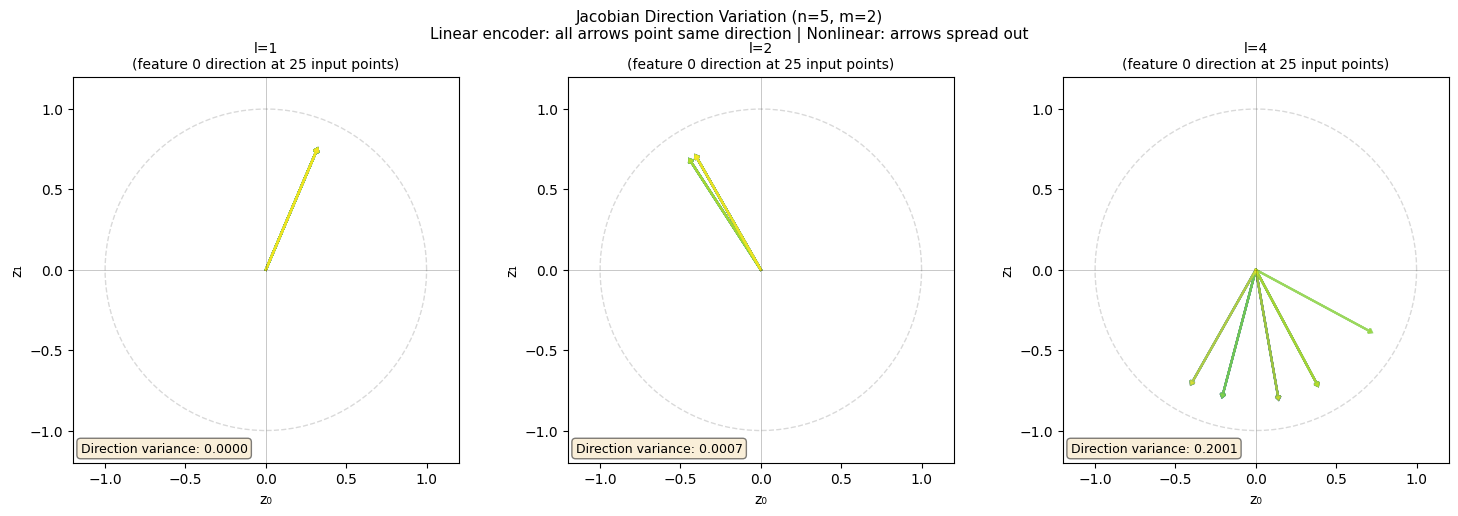


Jacobian Direction Variance for n=5 (0 = constant directions = linear):
  l=1: 0.000000
  l=2: 0.329661
  l=4: 0.211662


In [11]:
# Visualize Jacobian variation for different depths (uses n_to_show from above)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

n, m, S = n_to_show, 2, S_values[0]

for i, l in enumerate([1, 2, 4]):
    res = results.get((n, m, l, S))
    if res is None:
        continue

    model = res['model']
    var = visualize_jacobian_variation(model, n_samples=25, ax=axes[i], title=f"l={l}")

    axes[i].text(0.02, 0.02, f'Direction variance: {var:.4f}',
                transform=axes[i].transAxes, fontsize=9, verticalalignment='bottom',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle(f'Jacobian Direction Variation (n={n}, m={m})\n'
             'Linear encoder: all arrows point same direction | Nonlinear: arrows spread out',
             fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nJacobian Direction Variance for n={n} (0 = constant directions = linear):")
for l in [1, 2, 4]:
    res = results.get((n, m, l, S))
    if res:
        var = compute_jacobian_direction_variance(res['model'])
        print(f"  l={l}: {var:.6f}")

## 4. Reconstruction Comparison

Compare reconstruction quality across depths for various input types.

In [12]:
def plot_reconstruction_comparison(models_dict, test_inputs, input_labels=None):
    """Side-by-side comparison of reconstructions from different depths.

    Args:
        models_dict: dict mapping depth l to model
        test_inputs: (n_inputs, n_features) tensor
        input_labels: optional labels for each input
    """
    n_inputs = test_inputs.shape[0]
    n_models = len(models_dict)

    fig, axes = plt.subplots(n_inputs, n_models + 1, figsize=(3*(n_models+1), 2*n_inputs))

    depths = sorted(models_dict.keys())

    for i in range(n_inputs):
        x = test_inputs[i:i+1]
        x_np = x.cpu().numpy()[0]

        # Original
        ax = axes[i, 0] if n_inputs > 1 else axes[0]
        ax.bar(range(len(x_np)), x_np, color='steelblue', alpha=0.8)
        ax.set_ylim(0, 1.2)
        ax.set_title('Original' if i == 0 else '')
        if input_labels:
            ax.set_ylabel(input_labels[i], fontsize=9)

        # Reconstructions
        for j, l in enumerate(depths):
            model = models_dict[l]
            model.eval()
            with torch.no_grad():
                x_recon, z = model(x)
            x_recon_np = x_recon.cpu().numpy()[0]

            mse = np.mean((x_np - x_recon_np)**2)

            ax = axes[i, j+1] if n_inputs > 1 else axes[j+1]
            ax.bar(range(len(x_recon_np)), x_recon_np, color='coral', alpha=0.8)
            ax.bar(range(len(x_np)), x_np, color='steelblue', alpha=0.3, width=0.4)
            ax.set_ylim(0, 1.2)
            if i == 0:
                ax.set_title(f'l={l} (MSE={mse:.4f})')
            else:
                ax.set_title(f'MSE={mse:.4f}')

    plt.tight_layout()
    return fig

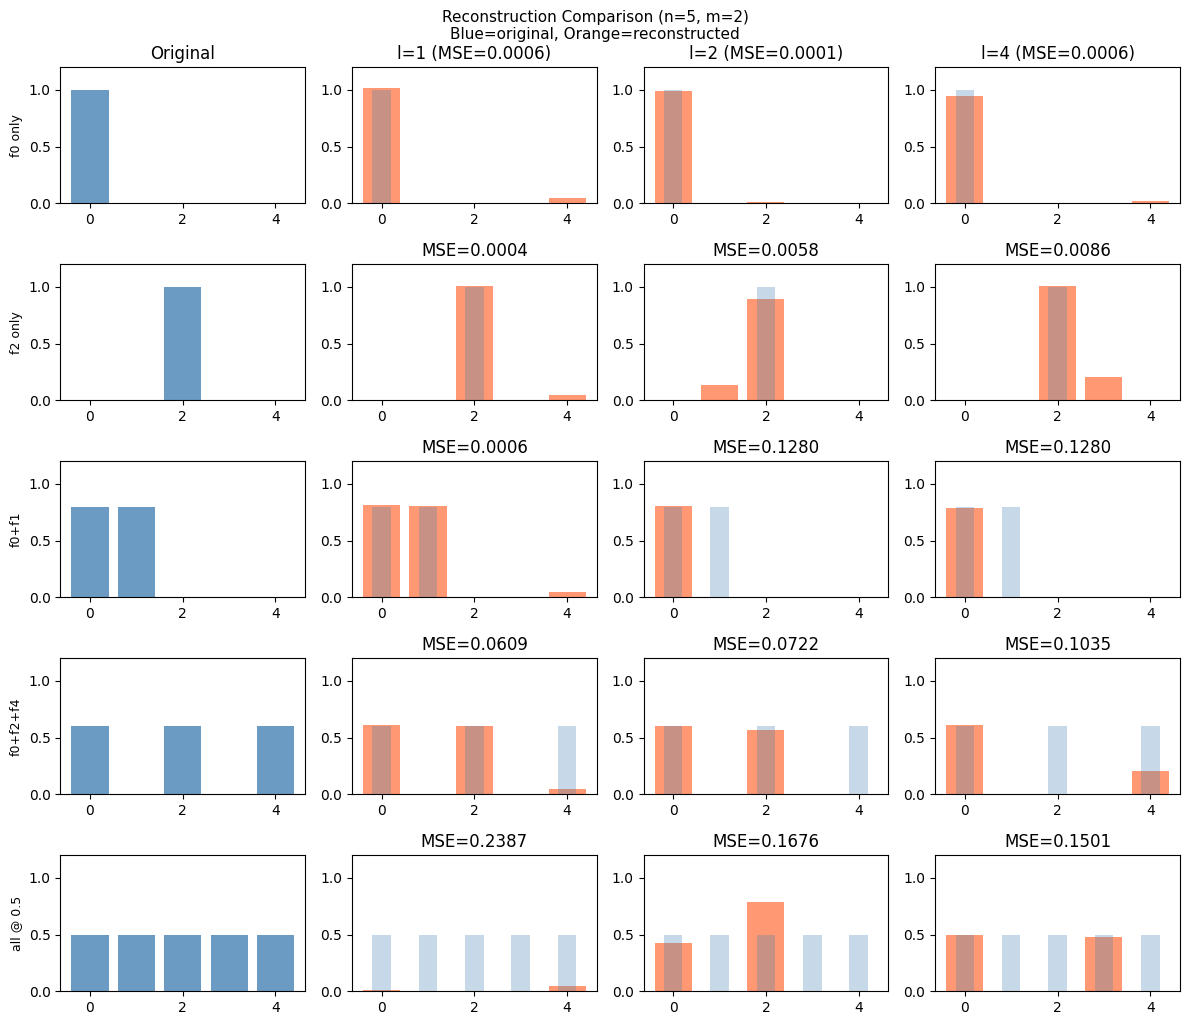

In [13]:
# Test reconstruction on different input patterns (uses n_to_show from above)
n, m, S = n_to_show, 2, S_values[0]

# Collect models for this config
models_dict = {}
for l in [1, 2, 4]:
    res = results.get((n, m, l, S))
    if res:
        models_dict[l] = res['model']

# Create test inputs
test_inputs = torch.zeros(5, n, device=device)

# Single features
test_inputs[0, 0] = 1.0
test_inputs[1, min(2, n-1)] = 1.0

# Pairs
test_inputs[2, 0] = 0.8
test_inputs[2, 1] = 0.8

# Triple (if n >= 3)
if n >= 3:
    test_inputs[3, 0] = 0.6
    test_inputs[3, n//2] = 0.6
    test_inputs[3, n-1] = 0.6

# Dense
test_inputs[4, :] = 0.5

input_labels = ['f0 only', f'f{min(2,n-1)} only', 'f0+f1', f'f0+f{n//2}+f{n-1}', 'all @ 0.5']

fig = plot_reconstruction_comparison(models_dict, test_inputs, input_labels)
fig.suptitle(f'Reconstruction Comparison (n={n}, m={m})\nBlue=original, Orange=reconstructed',
             y=1.02, fontsize=11)
plt.show()

## Summary: Nonlinearity Metrics Comparison

In [14]:
# Compile all nonlinearity metrics (uses n_to_show from above)
n, m, S = n_to_show, 2, S_values[0]

print(f"Configuration: n={n}, m={m}, S={S}")
print("=" * 70)
print(f"{'Metric':<35} {'l=1':>10} {'l=2':>10} {'l=4':>10}")
print("-" * 70)

# Collect metrics
metrics = {}
for l in [1, 2, 4]:
    res = results.get((n, m, l, S))
    if res:
        model = res['model']
        metrics[l] = {
            'final_loss': res['final_loss'],
            'linearity_score': res['linearity_score'],
            'nonlinear_gain': res['nonlinear_gain'],
            'jacobian_variance': res.get('jacobian_variance',
                                         compute_jacobian_direction_variance(model)),
            'trajectory_curvature': np.mean(compute_trajectory_curvature(model)),
            'additivity_violation': compute_additivity_violation(model),
        }

for metric in ['final_loss', 'linearity_score', 'nonlinear_gain',
               'trajectory_curvature', 'additivity_violation', 'jacobian_variance']:
    values = [metrics.get(l, {}).get(metric, float('nan')) for l in [1, 2, 4]]
    print(f"{metric:<35} {values[0]:>10.4f} {values[1]:>10.4f} {values[2]:>10.4f}")

print("-" * 70)
print("\nInterpretation:")
print("• linearity_score: how much variance in z is explained by linear fit (1.0 = linear)")
print("• nonlinear_gain: % MSE improvement from nonlinearity (0 = no benefit)")
print("• trajectory_curvature: arc/chord ratio (1.0 = straight lines)")
print("• additivity_violation: relative error in z(a+b) vs z(a)+z(b) (0 = additive)")
print("• jacobian_variance: variance in feature directions (0 = constant = linear)")

Configuration: n=5, m=2, S=0.9
Metric                                     l=1        l=2        l=4
----------------------------------------------------------------------
final_loss                              0.0023     0.0051     0.0013
linearity_score                         1.0000     0.9796     0.9342
nonlinear_gain                          0.0000     0.0482     0.5193
trajectory_curvature                    1.0000     1.0005     1.0747
additivity_violation                    0.0000     0.4839     0.5244
jacobian_variance                       0.0000     0.0918     0.5278
----------------------------------------------------------------------

Interpretation:
• linearity_score: how much variance in z is explained by linear fit (1.0 = linear)
• nonlinear_gain: % MSE improvement from nonlinearity (0 = no benefit)
• trajectory_curvature: arc/chord ratio (1.0 = straight lines)
• additivity_violation: relative error in z(a+b) vs z(a)+z(b) (0 = additive)
• jacobian_variance: variance in

## Investigation: Why do trajectories meet at a non-origin point?

All trajectories start from the same point because they all start from the same input: **x = [0, 0, 0, 0, 0]**. 

When we sweep feature i from 0→1, all other features stay at 0. So the starting point for ALL trajectories is z(0) = encode([0,0,0,0,0]).

For l=1 (linear, no bias), this is the origin. For l≥2, biases shift this point.

In [15]:
# Investigation 1: Where does z(0) = encode(zeros) land for each model?

n, m, S = n_to_show, 2, S_values[0]
x_zero = torch.zeros(1, n, device=device)

print(f"Where does the all-zeros input map to? (n={n})")
print("=" * 50)

for l in [1, 2, 4]:
    res = results.get((n, m, l, S))
    if res is None:
        continue
    model = res['model']
    with torch.no_grad():
        z_zero = model.encode(x_zero).cpu().numpy()[0]
    print(f"l={l}: z(0) = [{z_zero[0]:.4f}, {z_zero[1]:.4f}]")

print("\nThis explains why all trajectories meet at a common point!")
print("They all START from x=zeros, which maps to z(0).")

Where does the all-zeros input map to? (n=5)
l=1: z(0) = [0.0000, 0.0000]
l=2: z(0) = [0.4756, -0.3529]
l=4: z(0) = [-0.1602, 1.0213]

This explains why all trajectories meet at a common point!
They all START from x=zeros, which maps to z(0).


## Investigation: Why does l=2 look linear?

The l=2 encoder has structure: `x → Linear(n→n) → ReLU → Linear(n→m) → z`

ReLU is **piecewise linear**. If all the ReLU activations stay in the same "piece" (either all positive or all negative) as we sweep a feature from 0→1, the overall mapping is still linear!

Let's check: do the hidden activations cross zero (the ReLU kink) during the sweep?

In [16]:
# Investigation 2: Do hidden activations cross zero during feature sweeps?

def analyze_relu_crossings(model, feature_idx, n_points=50):
    """Check if any hidden unit crosses zero (ReLU kink) during a feature sweep."""
    if model.l < 2:
        return None, None
    
    first_linear = model.encoder[0]
    
    x = torch.zeros(n_points, model.n, device=device)
    x[:, feature_idx] = torch.linspace(0, 1, n_points)
    
    with torch.no_grad():
        h_pre = first_linear(x).cpu().numpy()
    
    crossings = []
    for unit in range(h_pre.shape[1]):
        signs = np.sign(h_pre[:, unit])
        n_crossings = np.sum(np.diff(signs) != 0)
        crossings.append(n_crossings)
    
    return h_pre, crossings

# Analyze l=2 model
n, m, S = n_to_show, 2, S_values[0]
res_l2 = results.get((n, m, 2, S))

if res_l2:
    model_l2 = res_l2['model']
    
    print(f"l=2 ReLU crossing analysis (n={n}):")
    print("=" * 60)
    print("For each feature sweep, how many hidden units cross zero?")
    print()
    
    total_crossings = 0
    for feat in range(n):
        h_pre, crossings = analyze_relu_crossings(model_l2, feat)
        n_crossing_units = sum(1 for c in crossings if c > 0)
        total_crossings += sum(crossings)
        print(f"Feature {feat}: {n_crossing_units}/{len(crossings)} units cross zero "
              f"(total crossings: {sum(crossings)})")
    
    print()
    if total_crossings == 0:
        print("NO hidden units cross zero during any sweep!")
        print("→ ReLU stays in a single linear regime → trajectory is straight")
    else:
        print(f"Total crossings: {total_crossings}")
        print("→ ReLU regime changes should cause curvature")

l=2 ReLU crossing analysis (n=5):
For each feature sweep, how many hidden units cross zero?

Feature 0: 1/5 units cross zero (total crossings: 1)
Feature 1: 0/5 units cross zero (total crossings: 0)
Feature 2: 1/5 units cross zero (total crossings: 1)
Feature 3: 0/5 units cross zero (total crossings: 0)
Feature 4: 0/5 units cross zero (total crossings: 0)

Total crossings: 2
→ ReLU regime changes should cause curvature


In [17]:
# Compare l=2 vs l=4: more layers = more chances to cross ReLU boundaries

def count_all_relu_crossings(model, feature_idx, n_points=50):
    """Count ReLU crossings across ALL hidden layers."""
    if model.l < 2:
        return 0
    
    x = torch.zeros(n_points, model.n, device=device)
    x[:, feature_idx] = torch.linspace(0, 1, n_points)
    
    total_crossings = 0
    
    with torch.no_grad():
        h = x
        for module in model.encoder:
            if isinstance(module, torch.nn.Linear):
                h = module(h)
            elif isinstance(module, torch.nn.ReLU):
                h_np = h.cpu().numpy()
                for unit in range(h_np.shape[1]):
                    signs = np.sign(h_np[:, unit])
                    crossings = np.sum(np.diff(signs) != 0)
                    total_crossings += crossings
                h = module(h)
    
    return total_crossings

n, m, S = n_to_show, 2, S_values[0]

print(f"\nComparing ReLU crossings across depths (n={n}):")
print("=" * 60)

for l in [2, 4]:
    res = results.get((n, m, l, S))
    if res is None:
        continue
    model = res['model']
    
    print(f"\nl={l} model:")
    for feat in range(n):
        crossings = count_all_relu_crossings(model, feat)
        print(f"  Feature {feat}: {crossings} total ReLU crossings")

print("\n" + "=" * 60)
print("More ReLU crossings → more curvature in trajectories")


Comparing ReLU crossings across depths (n=5):

l=2 model:
  Feature 0: 1 total ReLU crossings
  Feature 1: 0 total ReLU crossings
  Feature 2: 1 total ReLU crossings
  Feature 3: 0 total ReLU crossings
  Feature 4: 0 total ReLU crossings

l=4 model:
  Feature 0: 2 total ReLU crossings
  Feature 1: 2 total ReLU crossings
  Feature 2: 2 total ReLU crossings
  Feature 3: 2 total ReLU crossings
  Feature 4: 1 total ReLU crossings

More ReLU crossings → more curvature in trajectories


## Investigation: Why must trajectories share a starting point?

The trajectories MUST meet because of how we defined the visualization:
- Each trajectory sweeps ONE feature from 0→1
- All OTHER features are held at 0
- So ALL trajectories start from **the same input**: x = [0,0,0,0,0]

**Could features live in "separate regions"?** 

Not with this visualization method. But we can ask: what if we started each feature from a DIFFERENT baseline? Let's visualize trajectories that don't share a common starting point.

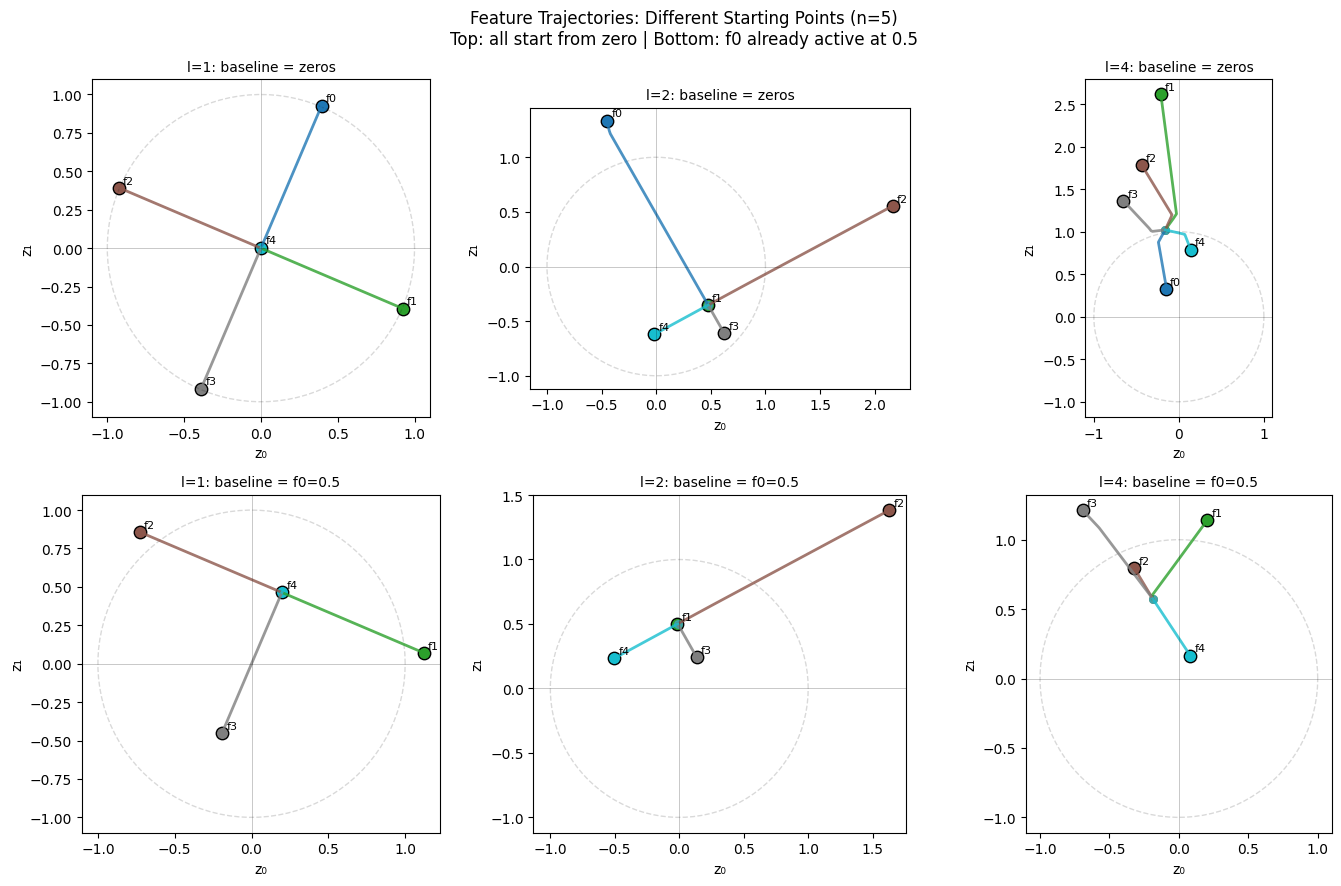

For a LINEAR encoder, changing the baseline just shifts all trajectories.
For a NONLINEAR encoder, trajectories can have different SHAPES depending on baseline!


In [18]:
# Alternative visualization: sweep each feature while ANOTHER feature is already active
# This shows how feature directions change in different regions of input space

def plot_feature_trajectories_with_context(model, context_feature=None, context_value=0.5, 
                                           n_points=50, ax=None, title=""):
    """Plot trajectories when another feature is already active."""
    model.eval()
    n_features = model.n

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    colors = plt.cm.tab10(np.linspace(0, 1, min(n_features, 10)))

    theta = np.linspace(0, 2*np.pi, 100)
    ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.15, linewidth=1)

    with torch.no_grad():
        for i in range(n_features):
            if i == context_feature:
                continue
                
            x = torch.zeros(n_points, n_features, device=device)
            x[:, i] = torch.linspace(0, 1, n_points)
            if context_feature is not None:
                x[:, context_feature] = context_value

            z = model.encode(x).cpu().numpy()

            color = colors[i % len(colors)]
            ax.plot(z[:, 0], z[:, 1], '-', color=color, linewidth=2, alpha=0.8)
            ax.scatter(z[0, 0], z[0, 1], color=color, s=30, marker='o', alpha=0.5)
            ax.scatter(z[-1, 0], z[-1, 1], color=color, s=80, marker='o', 
                      edgecolors='black', linewidth=1)
            ax.annotate(f'f{i}', (z[-1, 0], z[-1, 1]), fontsize=8,
                       xytext=(3, 3), textcoords='offset points')

    ax.axhline(y=0, color='k', linewidth=0.5, alpha=0.3)
    ax.axvline(x=0, color='k', linewidth=0.5, alpha=0.3)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('z₀')
    ax.set_ylabel('z₁')
    return ax


# Compare: trajectories from zero vs trajectories when f0 is already active
n, m, S = n_to_show, 2, S_values[0]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for col, l in enumerate([1, 2, 4]):
    res = results.get((n, m, l, S))
    if res is None:
        continue
    model = res['model']
    
    # Top row: baseline at zero (original)
    plot_feature_trajectories(model, ax=axes[0, col], 
                              title=f"l={l}: baseline = zeros")
    
    # Bottom row: baseline with f0=0.5 already active
    plot_feature_trajectories_with_context(model, context_feature=0, context_value=0.5,
                                           ax=axes[1, col],
                                           title=f"l={l}: baseline = f0=0.5")

fig.suptitle(f"Feature Trajectories: Different Starting Points (n={n})\n"
             "Top: all start from zero | Bottom: f0 already active at 0.5", 
             fontsize=12)
plt.tight_layout()
plt.show()

print("For a LINEAR encoder, changing the baseline just shifts all trajectories.")
print("For a NONLINEAR encoder, trajectories can have different SHAPES depending on baseline!")

## Summary of Findings

### Why do trajectories meet at a non-origin point?
- All trajectories start from the same input: x = [0,0,0,0,0]
- For l=1 (no bias), encode(0) = 0 (origin)
- For l≥2 (with biases), encode(0) ≠ 0 (biases shift the starting point)

### Why does l=2 still look linear?
- ReLU is **piecewise linear** - it's only nonlinear at x=0
- If no hidden unit crosses zero during the feature sweep, the entire trajectory stays in ONE linear piece
- l=2 may have learned weights where single-feature sweeps don't trigger ReLU crossings
- The nonlinearity only "activates" when COMBINATIONS of features are present

### Why can't features be in separate regions?
- They CAN be in separate regions! But our visualization forces them to share a starting point
- The key insight: a nonlinear encoder can have **context-dependent** feature directions
- Feature i's trajectory changes shape depending on what OTHER features are active
- This is the true power of nonlinearity: features interact differently in different input regions

## Decoder View: What features does each z-point reconstruct?

For each point in z-space, run it through the decoder and see what features get reconstructed. Color each point based on the feature composition of the reconstruction.

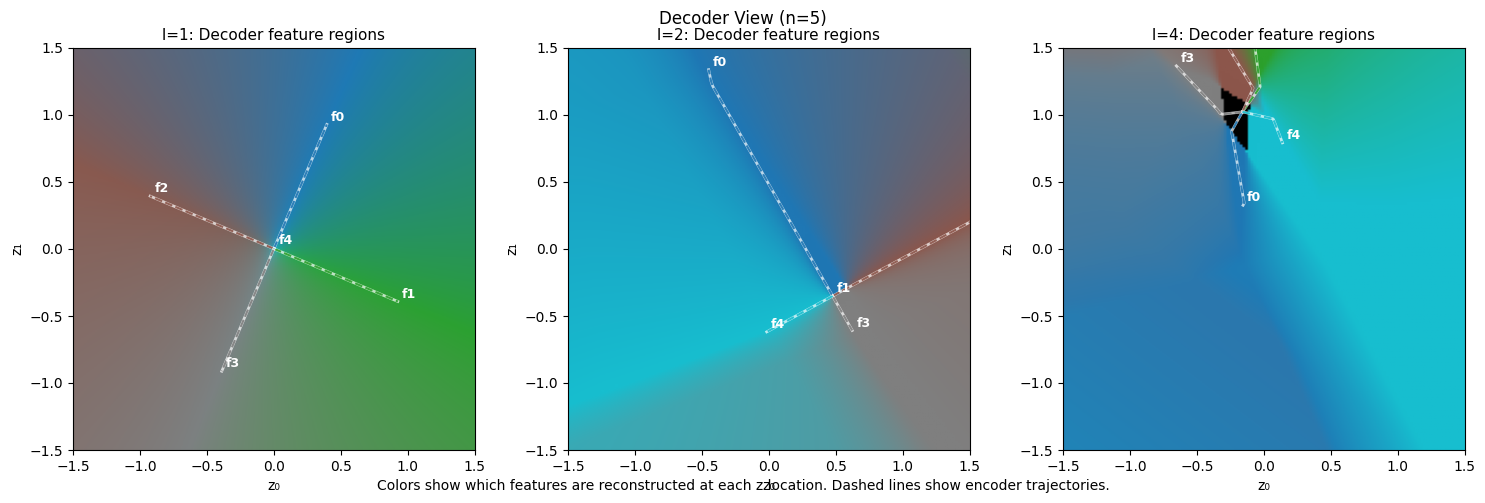

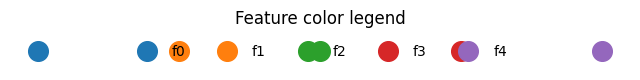

In [19]:
def plot_decoder_regions(model, z_range=(-2, 2), resolution=100, ax=None, title=""):
    """
    Visualize what features each point in z-space reconstructs.
    
    For each point z, compute x_reconstructed = decode(z), then color
    based on which features are active in the reconstruction.
    """
    model.eval()
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    
    z0 = np.linspace(z_range[0], z_range[1], resolution)
    z1 = np.linspace(z_range[0], z_range[1], resolution)
    Z0, Z1 = np.meshgrid(z0, z1)
    
    z_grid = torch.tensor(np.stack([Z0.flatten(), Z1.flatten()], axis=1), 
                          dtype=torch.float32, device=device)
    
    with torch.no_grad():
        x_recon = model.decode(z_grid).cpu().numpy()
    
    x_recon = np.maximum(x_recon, 0)
    
    x_sum = x_recon.sum(axis=1, keepdims=True) + 1e-8
    x_normalized = x_recon / x_sum
    
    n_features = model.n
    feature_colors = plt.cm.tab10(np.linspace(0, 1, n_features))[:, :3]
    
    rgb = np.zeros((resolution * resolution, 3))
    for i in range(n_features):
        rgb += x_normalized[:, i:i+1] * feature_colors[i]
    
    rgb_image = rgb.reshape(resolution, resolution, 3)
    
    ax.imshow(rgb_image, extent=[z_range[0], z_range[1], z_range[0], z_range[1]], 
              origin='lower', aspect='equal')
    
    # Overlay feature trajectories
    colors = plt.cm.tab10(np.linspace(0, 1, min(n_features, 10)))
    with torch.no_grad():
        for i in range(n_features):
            x = torch.zeros(50, n_features, device=device)
            x[:, i] = torch.linspace(0, 1, 50)
            z = model.encode(x).cpu().numpy()
            ax.plot(z[:, 0], z[:, 1], '-', color='white', linewidth=2, alpha=0.7)
            ax.plot(z[:, 0], z[:, 1], '--', color=colors[i], linewidth=1.5, alpha=0.9)
            ax.annotate(f'f{i}', (z[-1, 0], z[-1, 1]), fontsize=9, color='white',
                       fontweight='bold', xytext=(3, 3), textcoords='offset points')
    
    ax.set_xlabel('z₀')
    ax.set_ylabel('z₁')
    ax.set_title(title, fontsize=11)
    ax.set_xlim(z_range)
    ax.set_ylim(z_range)
    
    return ax, rgb_image


# Plot for all three depths (uses n_to_show)
n, m, S = n_to_show, 2, S_values[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, l in enumerate([1, 2, 4]):
    res = results.get((n, m, l, S))
    if res is None:
        continue
    model = res['model']
    
    plot_decoder_regions(model, z_range=(-1.5, 1.5), resolution=150, ax=axes[i],
                        title=f"l={l}: Decoder feature regions")

fig.text(0.5, 0.02, 'Colors show which features are reconstructed at each z location. '
         'Dashed lines show encoder trajectories.', ha='center', fontsize=10)
fig.suptitle(f'Decoder View (n={n})', fontsize=12)
plt.tight_layout()
plt.subplots_adjust(bottom=0.1)
plt.show()

# Color legend
fig_legend, ax_legend = plt.subplots(figsize=(8, 0.5))
for i in range(n):
    ax_legend.scatter([i], [0], c=[plt.cm.tab10(i/10)], s=200, label=f'f{i}')
ax_legend.legend(loc='center', ncol=n, frameon=False)
ax_legend.axis('off')
ax_legend.set_title('Feature color legend')
plt.show()

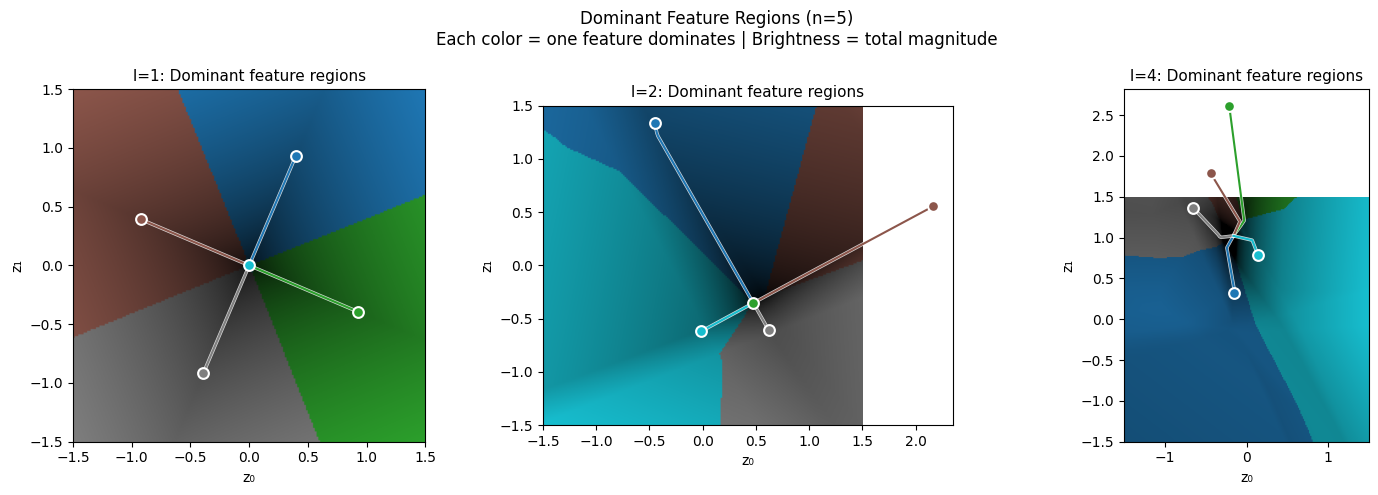

In [20]:
# Alternative: show dominant feature only (clearer regions)

def plot_dominant_feature_regions(model, z_range=(-2, 2), resolution=100, ax=None, title=""):
    """
    Color each z-point by the DOMINANT reconstructed feature.
    Brightness indicates total reconstruction magnitude.
    """
    model.eval()
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    
    z0 = np.linspace(z_range[0], z_range[1], resolution)
    z1 = np.linspace(z_range[0], z_range[1], resolution)
    Z0, Z1 = np.meshgrid(z0, z1)
    
    z_grid = torch.tensor(np.stack([Z0.flatten(), Z1.flatten()], axis=1), 
                          dtype=torch.float32, device=device)
    
    with torch.no_grad():
        x_recon = model.decode(z_grid).cpu().numpy()
    
    x_recon = np.maximum(x_recon, 0)
    
    dominant = np.argmax(x_recon, axis=1)
    total = x_recon.sum(axis=1)
    total_normalized = total / (total.max() + 1e-8)
    
    n_features = model.n
    feature_colors = plt.cm.tab10(np.linspace(0, 1, n_features))[:, :3]
    
    rgb = np.zeros((resolution * resolution, 3))
    for i in range(n_features):
        mask = dominant == i
        rgb[mask] = feature_colors[i]
    
    rgb = rgb * total_normalized[:, np.newaxis] ** 0.5
    rgb_image = rgb.reshape(resolution, resolution, 3)
    
    ax.imshow(rgb_image, extent=[z_range[0], z_range[1], z_range[0], z_range[1]], 
              origin='lower', aspect='equal')
    
    colors = plt.cm.tab10(np.linspace(0, 1, min(n_features, 10)))
    with torch.no_grad():
        for i in range(n_features):
            x = torch.zeros(50, n_features, device=device)
            x[:, i] = torch.linspace(0, 1, 50)
            z = model.encode(x).cpu().numpy()
            ax.plot(z[:, 0], z[:, 1], '-', color='white', linewidth=2.5, alpha=0.8)
            ax.plot(z[:, 0], z[:, 1], '-', color=colors[i], linewidth=1.5)
            ax.scatter(z[-1, 0], z[-1, 1], color=colors[i], s=60, 
                      edgecolors='white', linewidth=1.5, zorder=5)
    
    ax.set_xlabel('z₀')
    ax.set_ylabel('z₁')
    ax.set_title(title, fontsize=11)
    
    return ax


# Plot dominant feature version (uses n_to_show)
n, m, S = n_to_show, 2, S_values[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, l in enumerate([1, 2, 4]):
    res = results.get((n, m, l, S))
    if res is None:
        continue
    model = res['model']
    
    plot_dominant_feature_regions(model, z_range=(-1.5, 1.5), resolution=200, ax=axes[i],
                                  title=f"l={l}: Dominant feature regions")

fig.suptitle(f'Dominant Feature Regions (n={n})\n'
             'Each color = one feature dominates | Brightness = total magnitude', fontsize=12)
plt.tight_layout()
plt.show()

### What to look for:

**l=1 (linear decoder):** 
- Regions should have **straight boundaries** (linear decision boundaries)
- The decoder is just: `z @ W + b` followed by ReLU
- Each feature's "region" is a half-plane

**l≥2 (nonlinear decoder):**
- Regions could have **curved boundaries** 
- The decoder can carve out more complex shapes
- Features might have non-convex or discontinuous regions

**Key question:** Does the nonlinear decoder actually USE its nonlinearity to create different region shapes, or does it collapse to something linear-ish?

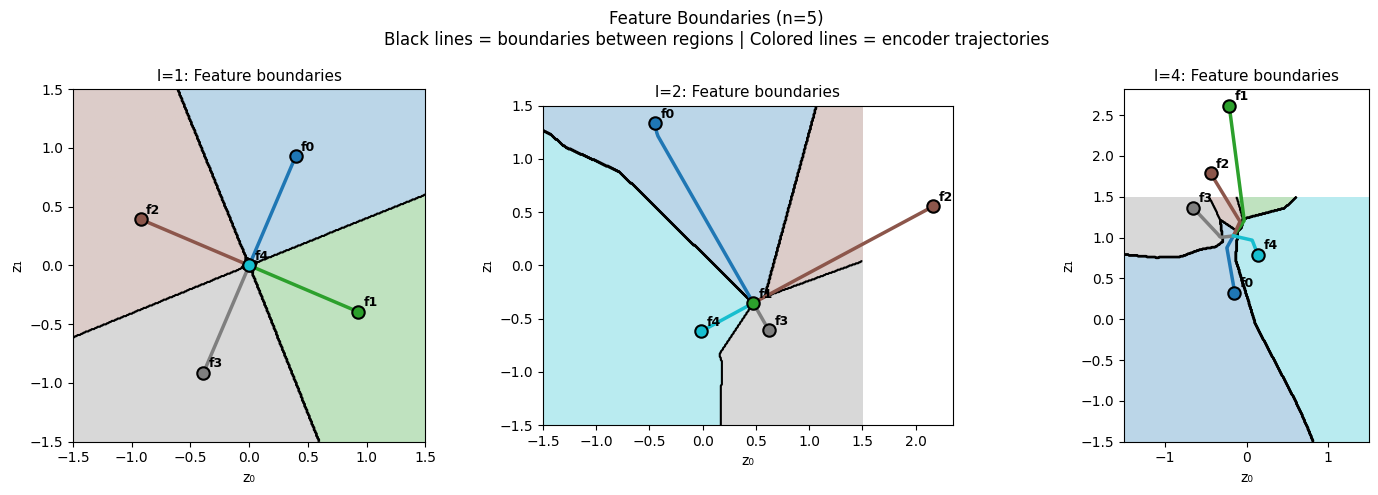


Look for:
• l=1: Straight boundary lines (linear decoder)
• l≥2: Potentially curved boundaries (nonlinear decoder)
• Do encoder trajectories stay within their feature's region?


In [21]:
# Show feature boundaries more explicitly

def plot_feature_boundaries(model, z_range=(-2, 2), resolution=200, ax=None, title=""):
    """
    Show where feature boundaries lie - where one feature stops dominating
    and another starts.
    """
    model.eval()
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    
    z0 = np.linspace(z_range[0], z_range[1], resolution)
    z1 = np.linspace(z_range[0], z_range[1], resolution)
    Z0, Z1 = np.meshgrid(z0, z1)
    
    z_grid = torch.tensor(np.stack([Z0.flatten(), Z1.flatten()], axis=1), 
                          dtype=torch.float32, device=device)
    
    with torch.no_grad():
        x_recon = model.decode(z_grid).cpu().numpy()
    
    x_recon = np.maximum(x_recon, 0)
    dominant = np.argmax(x_recon, axis=1).reshape(resolution, resolution)
    
    n_features = model.n
    feature_colors = plt.cm.tab10(np.linspace(0, 1, n_features))[:, :3]
    
    rgb = np.zeros((resolution, resolution, 3))
    for i in range(n_features):
        mask = dominant == i
        rgb[mask] = feature_colors[i] * 0.3 + 0.7
    
    ax.imshow(rgb, extent=[z_range[0], z_range[1], z_range[0], z_range[1]], 
              origin='lower', aspect='equal')
    
    ax.contour(Z0, Z1, dominant, levels=np.arange(-0.5, n_features), 
               colors='black', linewidths=1.5)
    
    colors = plt.cm.tab10(np.linspace(0, 1, min(n_features, 10)))
    with torch.no_grad():
        for i in range(n_features):
            x = torch.zeros(50, n_features, device=device)
            x[:, i] = torch.linspace(0, 1, 50)
            z = model.encode(x).cpu().numpy()
            ax.plot(z[:, 0], z[:, 1], '-', color=colors[i], linewidth=2.5)
            ax.scatter(z[-1, 0], z[-1, 1], color=colors[i], s=80, 
                      edgecolors='black', linewidth=1.5, zorder=5)
            ax.annotate(f'f{i}', (z[-1, 0], z[-1, 1]), fontsize=9,
                       xytext=(4, 4), textcoords='offset points', fontweight='bold')
    
    ax.set_xlabel('z₀')
    ax.set_ylabel('z₁')
    ax.set_title(title, fontsize=11)
    
    return ax


# Plot with explicit boundaries (uses n_to_show)
n, m, S = n_to_show, 2, S_values[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, l in enumerate([1, 2, 4]):
    res = results.get((n, m, l, S))
    if res is None:
        continue
    model = res['model']
    
    plot_feature_boundaries(model, z_range=(-1.5, 1.5), resolution=300, ax=axes[i],
                           title=f"l={l}: Feature boundaries")

fig.suptitle(f'Feature Boundaries (n={n})\n'
             'Black lines = boundaries between regions | Colored lines = encoder trajectories', 
             fontsize=12)
plt.tight_layout()
plt.show()

print("\nLook for:")
print("• l=1: Straight boundary lines (linear decoder)")
print("• l≥2: Potentially curved boundaries (nonlinear decoder)")
print("• Do encoder trajectories stay within their feature's region?")